In [2]:
from __future__ import annotations

import argparse
import math
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

from qualtran.bloqs.data_loading.qrom import QROM
from qualtran.resource_counting import QECGatesCost, get_cost_value

if (Path.cwd() / "src").exists():
    REPO_ROOT = Path.cwd()
elif (Path.cwd().parent / "src").exists():
    REPO_ROOT = Path.cwd().parent
else:
    REPO_ROOT = Path.cwd()

SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from exciton.benchmark_tensors import *

In [3]:
shape = (3, 3, )
R_loc = 5
R_c = 30

F = generate_f_tensor(shape, r_cut=R_loc, metric="euclidean")
V = generate_v_tensor(shape, r_loc=R_loc, r_c=R_c, metric="euclidean")

In [4]:
n = V.shape[0]
V_direct = V.reshape(n * n, n * n)  # (p, q) -> (r, s)
V_exchange = np.transpose(V, (0, 2, 1, 3)).reshape(n * n, n * n)  # (p, r) -> (q, s)

print("V tensor shape:", V.shape)
print("V_direct shape:", V_direct.shape)
print("V_exchange shape:", V_exchange.shape)


V tensor shape: (9, 9, 9, 9)
V_direct shape: (81, 81)
V_exchange shape: (81, 81)


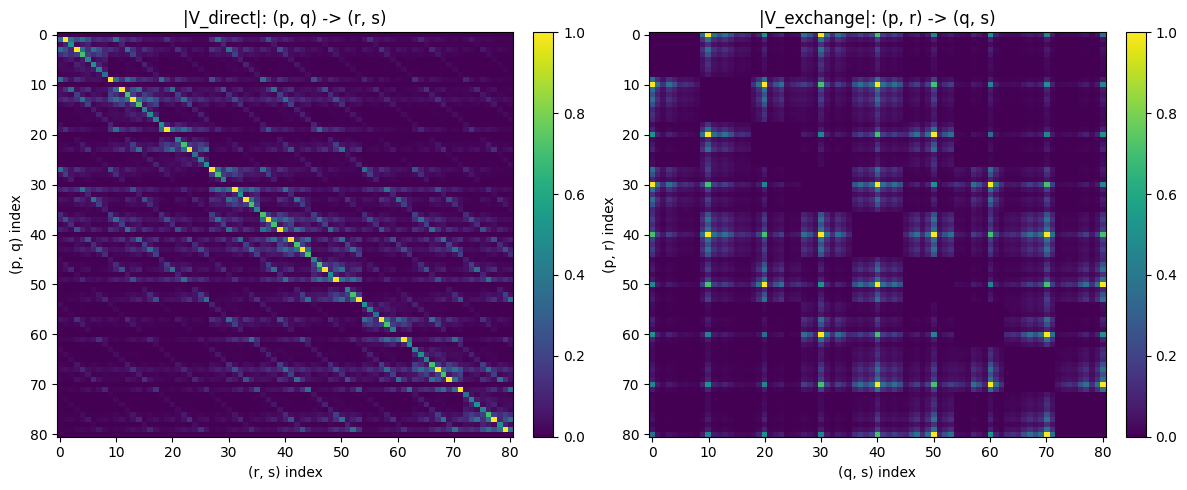

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(np.abs(V_direct), cmap="viridis", aspect="auto")
axes[0].set_title("|V_direct|: (p, q) -> (r, s)")
axes[0].set_xlabel("(r, s) index")
axes[0].set_ylabel("(p, q) index")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(np.abs(V_exchange), cmap="viridis", aspect="auto")
axes[1].set_title("|V_exchange|: (p, r) -> (q, s)")
axes[1].set_xlabel("(q, s) index")
axes[1].set_ylabel("(p, r) index")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


In [6]:



qrom = QROM.build_from_data(cols, 15)
gc = get_cost_value(qrom, QECGatesCost())


NameError: name 'cols' is not defined

In [ ]:
# Short Qualtran example: chain two 4-register oracles with BloqBuilder.

from attrs import frozen
from qualtran import Bloq, BloqBuilder, QUInt, Register, Signature

@frozen
class OracleA(Bloq):
    bitsize: int = 4

    @property
    def signature(self) -> Signature:
        return Signature([
            Register("i", QUInt(self.bitsize)),
            Register("j", QUInt(self.bitsize)),
            Register("k", QUInt(self.bitsize)),
            Register("t", QUInt(self.bitsize)),
        ])

    def call_classically(self, i, j, k, t):
        mod = 1 << self.bitsize
        return i, j, k, (int(t) + int(i) + 2 * int(j) + 3 * int(k)) % mod

@frozen
class OracleB(Bloq):
    bitsize: int = 4

    @property
    def signature(self) -> Signature:
        return Signature([
            Register("i", QUInt(self.bitsize)),
            Register("j", QUInt(self.bitsize)),
            Register("k", QUInt(self.bitsize)),
            Register("t", QUInt(self.bitsize)),
        ])

    def call_classically(self, i, j, k, t):
        mod = 1 << self.bitsize
        return i, j, k, (int(t) + int(i) * int(j) + int(k)) % mod

A = OracleA(bitsize=4)
B = OracleB(bitsize=4)

# Classical check of chained action: B(A(i,j,k,t)).
x0 = (2, 1, 3, 0)
x1 = A.call_classically(*x0)
x2 = B.call_classically(*x1)
print('input      :', x0)
print('after A    :', x1)
print('after B(A) :', x2)

# Circuit-level chaining in Qualtran via BloqBuilder.
bb = BloqBuilder()
i = bb.add_register('i', 4)
j = bb.add_register('j', 4)
k = bb.add_register('k', 4)
t = bb.add_register('t', 4)

out_a = bb.add_d(A, i=i, j=j, k=k, t=t)
out_b = bb.add_d(B, **out_a)
chained_cbloq = bb.finalize(**out_b)
print('chained signature:', chained_cbloq.signature)


input      : (2, 1, 3, 0)
after A    : (2, 1, 3, 13)
after B(A) : (2, 1, 3, 2)
chained signature: Signature((Register(name='i', dtype=QAny(bitsize=4), _shape=(), side=<Side.THRU: 3>), Register(name='j', dtype=QAny(bitsize=4), _shape=(), side=<Side.THRU: 3>), Register(name='k', dtype=QAny(bitsize=4), _shape=(), side=<Side.THRU: 3>), Register(name='t', dtype=QAny(bitsize=4), _shape=(), side=<Side.THRU: 3>)))


In [7]:
# End-to-end pipeline: chain several Bloqs -> gate counts -> surface-code costs.

from qualtran import BloqBuilder
from qualtran.resource_counting import GateCounts, QECGatesCost, get_cost_value
from qualtran.surface_code import CCZ2TFactory, MultiFactory, SimpleDataBlock
from qualtran.surface_code.gidney_fowler_model import get_ccz2t_costs

bitsize = 4
query_repetitions = 50_000  # scale this to model the full algorithm workload

A = OracleA(bitsize=bitsize)
B = OracleB(bitsize=bitsize)

# 1) Build one query as a chain of several Bloqs.
bb = BloqBuilder()
state = {
    'i': bb.add_register('i', bitsize),
    'j': bb.add_register('j', bitsize),
    'k': bb.add_register('k', bitsize),
    't': bb.add_register('t', bitsize),
}

for bloq in [A, B, A, B]:
    state = bb.add_d(bloq, **state)

query_cbloq = bb.finalize(**state)

# 2) Compile/count at QEC gate model level.
qec = get_cost_value(query_cbloq, QECGatesCost())
qec_dict = qec.asdict() if hasattr(qec, 'asdict') else vars(qec)

toffoli_per_query = int(
    qec_dict.get('toffoli', 0) + qec_dict.get('and_bloq', 0) + qec_dict.get('cswap', 0)
)
# If explicit T is unavailable in this Qualtran version, use a conservative proxy from Toffoli.
t_per_query = int(qec_dict.get('t', 4 * toffoli_per_query))

total_toffoli = toffoli_per_query * query_repetitions
total_t = t_per_query * query_repetitions

# 3) Surface-code compilation (runtime + physical footprint).
# Logical qubits: lower bound from explicit algorithm registers in this toy example.
n_algo_qubits = 4 * bitsize

factory = MultiFactory(
    base_factory=CCZ2TFactory(distillation_l1_d=19, distillation_l2_d=31),
    n_factories=4,
)
data_block = SimpleDataBlock(data_d=31, routing_overhead=0.5)

pcost = get_ccz2t_costs(
    n_logical_gates=GateCounts(toffoli=total_toffoli),
    n_algo_qubits=n_algo_qubits,
    phys_err=1e-3,
    cycle_time_us=1.0,
    factory=factory,
    data_block=data_block,
)

print('--- Per-query costs ---')
print('QEC counts:', qec_dict)
print('toffoli_per_query:', toffoli_per_query)
print('t_per_query (or proxy):', t_per_query)

print('\n--- Scaled algorithm costs ---')
print('query_repetitions:', query_repetitions)
print('total_toffoli:', total_toffoli)
print('total_t:', total_t)
print('logical_qubits (algo lower bound):', n_algo_qubits)
print('wall_time_hours:', pcost.duration_hr)
print('wall_time_days:', pcost.duration_hr / 24.0)
print('physical_qubits:', pcost.footprint)
print('physical_qubits_million:', pcost.footprint / 1e6)
print('failure_probability:', pcost.failure_prob)


NameError: name 'OracleA' is not defined

In [8]:
# How to combine multiple Bloqs into one CompositeBloq.

def combine_bloqs_to_single_bloq(bloq_sequence, bitsize=4):
    """Return one CompositeBloq equivalent to applying bloq_sequence in order."""
    bb = BloqBuilder()
    state = {
        'i': bb.add_register('i', bitsize),
        'j': bb.add_register('j', bitsize),
        'k': bb.add_register('k', bitsize),
        't': bb.add_register('t', bitsize),
    }

    for bloq in bloq_sequence:
        state = bb.add_d(bloq, **state)

    return bb.finalize(**state)

combined = combine_bloqs_to_single_bloq([OracleA(4), OracleB(4), OracleA(4)], bitsize=4)
print('combined bloq type:', type(combined).__name__)
print('combined signature:', combined.signature)

combined_qec = get_cost_value(combined, QECGatesCost())
print('combined QEC counts:', combined_qec.asdict() if hasattr(combined_qec, 'asdict') else vars(combined_qec))


NameError: name 'OracleA' is not defined

In [9]:
# Demo: apply a Bloq to only a subset of registers.

@frozen
class OracleSubsetIT(Bloq):
    bitsize: int = 4

    @property
    def signature(self) -> Signature:
        return Signature([
            Register("i", QUInt(self.bitsize)),
            Register("t", QUInt(self.bitsize)),
        ])

    def call_classically(self, i, t):
        mod = 1 << self.bitsize
        return i, (int(t) + 5 * int(i) + 1) % mod

subset_bloq = OracleSubsetIT(bitsize=4)

bb = BloqBuilder()
state = {
    'i': bb.add_register('i', 4),
    'j': bb.add_register('j', 4),
    'k': bb.add_register('k', 4),
    't': bb.add_register('t', 4),
    'flag': bb.add_register('flag', 1),
}

# Apply only on i,t. j,k,flag are carried through unchanged.
subset_out = bb.add_d(subset_bloq, i=state['i'], t=state['t'])
state.update(subset_out)  # updates i,t only

# You can continue with a full-register bloq afterward.
full_out = bb.add_d(OracleA(4), i=state['i'], j=state['j'], k=state['k'], t=state['t'])
state.update(full_out)  # preserves flag

subset_pipeline = bb.finalize(**state)
print('subset pipeline signature:', subset_pipeline.signature)

# Optional: gate counting needs decomposable/component costable Bloqs.
try:
    subset_qec = get_cost_value(subset_pipeline, QECGatesCost())
    print('subset pipeline counts:', subset_qec.asdict() if hasattr(subset_qec, 'asdict') else vars(subset_qec))
except Exception as exc:
    print('QEC count unavailable for this toy oracle set:', type(exc).__name__, exc)


NameError: name 'frozen' is not defined

In [10]:
# Two-particle row entry oracle (stored in src/block_encoding).
import numpy as np

from integrations.qualtran.block_encoding.two_particle_row_oracles import (
    TwoParticleRowEntryOracle,
    build_two_particle_row_entry_oracle,
)

# Small demo (kept tiny for memory):
D_demo, L_demo, Rc_demo, Rloc_demo = 2, 3, 1, 1
shape_demo = (L_demo,) * D_demo + (L_demo,) * D_demo + (2 * Rc_demo + 1,) * D_demo + (2 * Rloc_demo + 1,) * D_demo
M_demo = 0.1 * np.ones(shape_demo, dtype=np.float64)  # must be in [0,1] for this decomposition
entry_bloq = build_two_particle_row_entry_oracle(M_demo, D_demo, L_demo, Rc_demo, Rloc_demo, entry_bitsize=8)
print('entry bloq type:', type(entry_bloq).__name__)
print('entry bloq signature:', entry_bloq.signature)
print('sample entry M[i,j,m,l]=', entry_bloq.entry_value(i=(1, 2), j=(0, 1), m=(1, 2), l=(0, 1)))


entry bloq signature: Signature((Register(name='q', dtype=QBit(), _shape=(), side=<Side.THRU: 3>), Register(name='m', dtype=BQUInt(bitsize=2, iteration_length=3), _shape=(2,), side=<Side.THRU: 3>), Register(name='l', dtype=BQUInt(bitsize=2, iteration_length=3), _shape=(2,), side=<Side.THRU: 3>), Register(name='i', dtype=BQUInt(bitsize=2, iteration_length=3), _shape=(2,), side=<Side.THRU: 3>), Register(name='j', dtype=BQUInt(bitsize=2, iteration_length=3), _shape=(2,), side=<Side.THRU: 3>)))
sample entry M[i,j,m,l]= 0.1


In [11]:
# Demo: T-gate count for TwoParticleRowEntryOracle
from qualtran.resource_counting import QECGatesCost, get_cost_value

if 'entry_bloq' not in globals():
    raise RuntimeError("Run the TwoParticleRowEntryOracle construction cell first (defines `entry_bloq`).")

qec = get_cost_value(entry_bloq, QECGatesCost())
qec_dict = qec.asdict() if hasattr(qec, 'asdict') else vars(qec)

toffoli_like = int(qec_dict.get('toffoli', 0) + qec_dict.get('and_bloq', 0) + qec_dict.get('cswap', 0))
t_explicit = int(qec_dict.get('t', 0))
t_gate_estimate = t_explicit + 4 * toffoli_like

print('TwoParticleRowEntryOracle QEC counts:', qec_dict)
print('Toffoli-like count           :', toffoli_like)
print('Explicit T count             :', t_explicit)
print('Estimated T count (T + 4*Toff):', t_gate_estimate)


TensorEntryOracleBloq QEC counts: {'clifford': 12, 'rotation': 8}
Toffoli-like count           : 0
Explicit T count             : 0
Estimated T count (T + 4*Toff): 0
